In [99]:
from langgraph.graph import StateGraph, END
from jinja2 import Template, Environment, FileSystemLoader
from typing import List, Dict, Any
from pathlib import Path

In [100]:
import os
import sys
sys.path.append(os.path.abspath(".."))

In [101]:
from agent.states import GlobalState

In [102]:
template_dir = (Path.cwd().parent / "agent" / "templates").resolve()
print("Template dir:", template_dir)

Template dir: C:\Users\hp\OneDrive\Desktop\anmol\Automated-Software-Design\Automated-System-Design\backend\agent\templates


In [103]:
env = Environment(
    loader=FileSystemLoader(searchpath=str(template_dir)),
    trim_blocks=True,
    lstrip_blocks=True
)

In [104]:
# Common example input aligned with GlobalState and planning/design schemas
sample_output_state = {
	"user_input": "Design a social app for pet owners to share updates and photos.",
    "requirements": {
        "problem": "Build a social app for pet owners to share updates and photos",
        "users": ["pet owners", "pet enthusiasts"],
        "features": [
            "user authentication",
            "pet profiles",
            "photo uploads",
            "social feed",
            "follow connections",
            "notifications"
        ],
        "scale_hint": "~10,000 DAU",
        "domain": "social_media"
    },
    "constraints": {
        "scale": "10k daily active users",
        "latency": "p95 under 200ms for core read APIs",
        "budget": "moderate",
        "team_size": "small",
        "security": "JWT auth, encrypted storage, OWASP basics"
    },
    "architecture": {
        "pattern": "microservices",
        "modules": [
            "auth",
            "pet-profile",
            "media",
            "feed",
            "social-graph",
            "notifications"
        ],
        "reasoning": "Independent scaling for feed and media services with clear bounded contexts.",
        "confidence": 0.83
    },
    "tech_stack": {
        "frontend": {
            "language": "TypeScript",
            "framework": "Next.js",
            "reasoning": "SSR plus a strong React ecosystem for fast UI delivery."
        },
        "backend": {
            "language": "Python",
            "framework": "FastAPI",
            "api_style": "REST",
            "reasoning": "Fast development, async support, and clean schema-based APIs."
        },
        "database": {
            "type": "relational",
            "name": "PostgreSQL",
            "orm": "SQLAlchemy",
            "reasoning": "Strong consistency for user, feed, and relationship data."
        },
        "infra": {
            "provider": "AWS",
            "services": ["EKS", "RDS", "S3", "CloudFront"],
            "reasoning": "Managed compute, durable storage, and scalable delivery."
        },
        "overall_reasoning": "Stack is aligned with microservices, moderate budget, and target scale.",
        "confidence": 0.86
    },
    "design_bundle": {
		"services": {
			"services": [
				{
					"name": "auth-service",
					"responsibility": "Authentication and token management",
					"owned_data": ["users", "sessions"],
					"dependencies": [],
					"key_patterns": "JWT + refresh token rotation"
				},
				{
					"name": "feed-service",
					"responsibility": "Timeline and post retrieval",
					"owned_data": ["posts", "reactions"],
					"dependencies": ["social-graph-service", "media-service"],
					"key_patterns": "fan-out on write + caching"
				}
			],
			"reasoning": "Clear separation of concerns with minimal dependencies for core services.",
			"confidence": 0.88
		},
        "database_schema": {
            "tables": [
                {
                    "name": "users",
                    "description": "Registered user accounts",
                    "fields": ["id: uuid, pk", "email: varchar", "password_hash: varchar"],
                    "relations": []
                },
                {
                    "name": "pets",
                    "description": "Pet profiles owned by users",
                    "fields": ["id: uuid, pk", "owner_id: uuid, fk", "name: varchar", "species: varchar"],
                    "relations": ["pets.owner_id -> users.id"]
                },
                {
                    "name": "photos",
                    "description": "Pet media metadata",
                    "fields": ["id: uuid, pk", "pet_id: uuid, fk", "s3_key: varchar", "created_at: timestamp"],
                    "relations": ["photos.pet_id -> pets.id"]
                }
            ],
            "reasoning": "Normalized core entities with explicit ownership and relations.",
            "confidence": 0.9
        },
        "api_endpoints": {
			"api_design": [
				{"name": "Create User", "purpose": "Register a new user", "base_route": "/api/users"},
				{"name": "Create Pet Profile", "purpose": "Create a pet profile", "base_route": "/api/pets"},
				{"name": "Upload Photo", "purpose": "Upload pet photos", "base_route": "/api/photos"}
			],
			"frontend_notes": "Endpoints are designed around core entities and user actions.",
			"reasoning": "Endpoints are designed around core entities and user actions.",
			"confidence": 0.87
		},
        "infrastructure": {
            "cloud": "AWS",
            "services": ["EKS", "RDS (PostgreSQL)", "S3", "CloudFront"],
            "deployment": "Dockerized services on EKS with managed PostgreSQL and object storage.",
            "reasoning": "Managed services reduce ops burden and support scaling.",
            "confidence": 0.87
        }
    },
    "final_score": 0.88
}

In [105]:
# ======== Output Graph States ========
class OutputState(GlobalState):
    final_output_report: str

In [106]:
# # Node function to render the output json into a human-readable format (e.g., Markdown or HTML).
# def output_renderer_node(data: Dict[str, Any] | List | str, tabs: int = 1) -> str:
#   tab_str = "&emsp;" * tabs

#   if isinstance(data, dict):
#     rendered = "".join([
# 	  f"\n{tab_str}**{key.replace('_', ' ').capitalize()}:** {output_renderer_node(value, tabs + 1)}\n" for key, value in data.items()
#     ])
#     return rendered
  
#   elif isinstance(data, list):
#     rendered = "\n".join([f"\n{tab_str}- {output_renderer_node(item, tabs)}" for item in data])
#     return "\n" + rendered
  
#   else:
#     return str(data)

# helper function to render any dict data into markdown using the appropriate Jinja2 template
def render_dict_to_markdown(data: Any, template_name: str) -> str:
	template = env.get_template(template_name)
     
	key_map = {
        "requirements_output.j2": "requirements",
        "constraints_output.j2": "constraints",
        "architecture_output.j2": "architecture",
        "tech_stack_output.j2": "tech_stack",
        "design_bundle_output.j2": "design_bundle",
    }
	key = key_map.get(template_name, "data")

	return template.render(**{key: data})

# Node function to assemble all generated outputs into a final structured format.
def output_assembler_node(state: OutputState) -> Dict:
  # In a real implementation, this would involve more complex logic to format the output report.
  # For demonstration, we will just merge all available information into a single human readable report.

  md_data = {
    "user_input": state.get("user_input", "N/A"),
	"requirements": render_dict_to_markdown(state.get("requirements", "N/A"), template_name="requirements_output.j2"),
	"architecture": render_dict_to_markdown(state.get("architecture", "N/A"), template_name="architecture_output.j2"),
	"tech_stack": render_dict_to_markdown(state.get("tech_stack", "N/A"), template_name="tech_stack_output.j2"),
	"design_bundle": render_dict_to_markdown(state.get("design_bundle", "N/A"), template_name="design_bundle_output.j2"),
	"final_score": state.get("final_score", "N/A")
  }

  final_report = render_dict_to_markdown(md_data, template_name="final_report_output.j2")

  return {
    "final_output_report": final_report
  }

In [107]:
report = output_assembler_node(sample_output_state)

In [108]:
print(report['final_output_report'])

# System Design Report

### User Input
Design a social app for pet owners to share updates and photos.

## Requirements

**Problem**: Build a social app for pet owners to share updates and photos

**Users**
- pet owners
- pet enthusiasts

**Features**
- user authentication
- pet profiles
- photo uploads
- social feed
- follow connections
- notifications

**Scale Hint**: ~10,000 DAU

**Domain**: social_media

## Architecture

**Pattern**: microservices

### Modules
- auth
- pet-profile
- media
- feed
- social-graph
- notifications

**Reasoning**: Independent scaling for feed and media services with clear bounded contexts.

**Confidence**: 0.83

## Tech Stack

**Frontend**
- Language: TypeScript
- Framework: Next.js
- Reasoning: SSR plus a strong React ecosystem for fast UI delivery.

**Backend**
- Language: Python
- Framework: FastAPI
- API Style: REST
- Reasoning: Fast development, async support, and clean schema-based APIs.

**Database**
- Type: relational
- Name: PostgreSQL
- ORM: SQ

# System Design Report

### User Input
Design a social app for pet owners to share updates and photos.

## Requirements

**Problem**: Build a social app for pet owners to share updates and photos

**Users**
- pet owners
- pet enthusiasts

**Features**
- user authentication
- pet profiles
- photo uploads
- social feed
- follow connections
- notifications

**Scale Hint**: ~10,000 DAU

**Domain**: social_media

## Architecture

**Pattern**: microservices

### Modules
- auth
- pet-profile
- media
- feed
- social-graph
- notifications

**Reasoning**: Independent scaling for feed and media services with clear bounded contexts.

**Confidence**: 0.83

## Tech Stack

**Frontend**
- Language: TypeScript
- Framework: Next.js
- Reasoning: SSR plus a strong React ecosystem for fast UI delivery.

**Backend**
- Language: Python
- Framework: FastAPI
- API Style: REST
- Reasoning: Fast development, async support, and clean schema-based APIs.

**Database**
- Type: relational
- Name: PostgreSQL
- ORM: SQLAlchemy
- Reasoning: Strong consistency for user, feed, and relationship data.

**Infrastructure**
- Provider: AWS
- Services:
  - EKS
  - RDS
  - S3
  - CloudFront
- Reasoning: Managed compute, durable storage, and scalable delivery.

**Overall Reasoning**
Stack is aligned with microservices, moderate budget, and target scale.

**Confidence**
0.86

## Design Bundle

### Services
- Name: auth-service
  - Responsibility: Authentication and token management
  - Owned Data:
    - users
    - sessions
  - Dependencies:
    - None
  - Key Patterns: JWT + refresh token rotation
- Name: feed-service
  - Responsibility: Timeline and post retrieval
  - Owned Data:
    - posts
    - reactions
  - Dependencies:
    - social-graph-service
    - media-service
  - Key Patterns: fan-out on write + caching
- Reasoning: Clear separation of concerns with minimal dependencies for core services.
- Confidence: 0.88

### Database Schema
- Name: users
  - Description: 
  - Fields:
    - id: uuid, pk
    - email: varchar
    - password_hash: varchar
  - Relations:
    - None
- Name: pets
  - Description: 
  - Fields:
    - id: uuid, pk
    - owner_id: uuid, fk
    - name: varchar
    - species: varchar
  - Relations:
    - pets.owner_id -> users.id
- Name: photos
  - Description: 
  - Fields:
    - id: uuid, pk
    - pet_id: uuid, fk
    - s3_key: varchar
    - created_at: timestamp
  - Relations:
    - photos.pet_id -> pets.id
- Reasoning: Normalized core entities with explicit ownership and relations.
- Confidence: 0.9

### API Endpoints
- Name: Create User
  - Purpose: Register a new user
  - Base Route: /api/users
- Name: Create Pet Profile
  - Purpose: Create a pet profile
  - Base Route: /api/pets
- Name: Upload Photo
  - Purpose: Upload pet photos
  - Base Route: /api/photos
- Frontend Notes: Endpoints are designed around core entities and user actions.
- Reasoning: Endpoints are designed around core entities and user actions.
- Confidence: 0.87

### Infrastructure
- Cloud: AWS
- Services:
  - EKS
  - RDS (PostgreSQL)
  - S3
  - CloudFront
- Deployment: Dockerized services on EKS with managed PostgreSQL and object storage.
- Reasoning: Managed services reduce ops burden and support scaling.
- Confidence: 0.87

**Final Score**: 0.88%

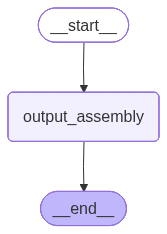

In [109]:
# =========== Graph Construction ===========
output_graph = StateGraph(OutputState)

output_graph.add_node("output_assembly", output_assembler_node)
output_graph.set_entry_point("output_assembly")
output_graph.add_edge("output_assembly", END)

output_stage = output_graph.compile()
output_stage